<a href="https://colab.research.google.com/github/rafiatoumalamali-cell/lab-3/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Rafiatou Malam Ali
**Student ID:** 30782027

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split
# Scikit-learn (import as needed)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)  # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

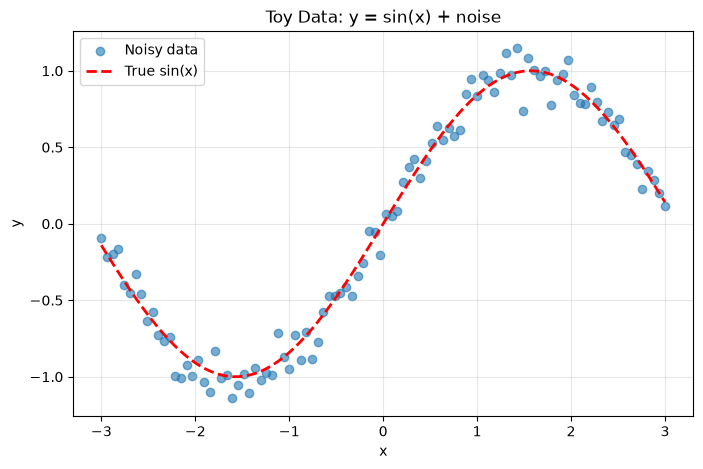

Initial w: 0.2484, b: -0.0691
Step   0, Loss: 0.224068, w: 0.3039, b: -0.0574
Step  20, Loss: 0.195452, w: 0.3390, b: -0.0109
Step  40, Loss: 0.195452, w: 0.3390, b: -0.0104
Step  60, Loss: 0.195452, w: 0.3390, b: -0.0104
Step  80, Loss: 0.195452, w: 0.3390, b: -0.0104
Step 100, Loss: 0.195452, w: 0.3390, b: -0.0104
Step 120, Loss: 0.195452, w: 0.3390, b: -0.0104
Step 140, Loss: 0.195452, w: 0.3390, b: -0.0104
Step 160, Loss: 0.195452, w: 0.3390, b: -0.0104
Step 180, Loss: 0.195452, w: 0.3390, b: -0.0104


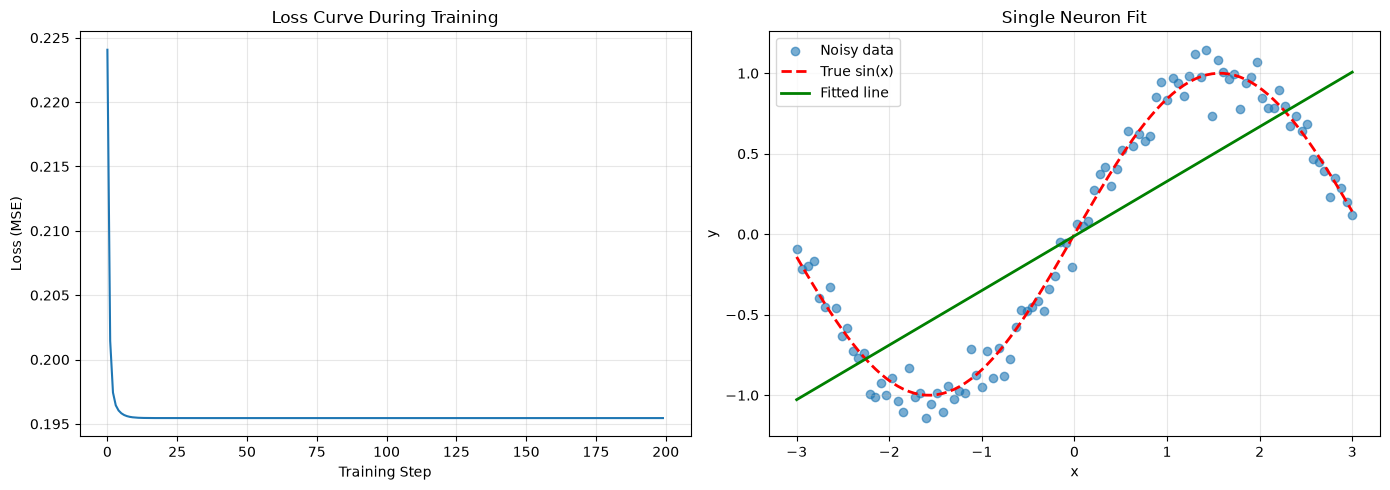


Final w: 0.3390, b: -0.0104
Final loss: 0.195452


In [2]:
# TODO 1: Generate the toy data
x = np.linspace(-3, 3, 100)
noise = np.random.randn(100) * 0.1
y = np.sin(x) + noise

# Plot the data
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.6, label="Noisy data")
plt.plot(x, np.sin(x), "r--", label="True sin(x)", linewidth=2)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Toy Data: y = sin(x) + noise")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# TODO 2: Initialise w and b to small random values.
np.random.seed(42)  # For reproducible results
w = np.random.randn() * 0.5  # Random weight
b = np.random.randn() * 0.5  # Random bias
lr = 0.1  # Learning rate
loss_history = []  # To store loss at each step
print(f"Initial w: {w:.4f}, b: {b:.4f}")

# TODO 3: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
for step in range(200):
    # Forward pass: compute predictions
    y_hat = w * x + b

    # Compute loss (Mean Squared Error)
    loss = np.mean((y_hat - y) ** 2)
    loss_history.append(loss)  # Record loss

    # Compute gradients (backward pass)
    dw = np.mean(2 * (y_hat - y) * x)  # dLoss/dw
    db = np.mean(2 * (y_hat - y))  # dLoss/db

    # Update parameters
    w = w - lr * dw
    b = b - lr * db

    # Print progress every 20 steps
    if step % 20 == 0:
        print(f"Step {step:3d}, Loss: {loss:.6f}, w: {w:.4f}, b: {b:.4f}")

# TODO 4: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot (a): Loss curve
ax1.plot(loss_history)
ax1.set_xlabel("Training Step")
ax1.set_ylabel("Loss (MSE)")
ax1.set_title("Loss Curve During Training")
ax1.grid(True, alpha=0.3)

# Plot (b): Data with fitted line
ax2.scatter(x, y, alpha=0.6, label="Noisy data")
ax2.plot(x, np.sin(x), "r--", label="True sin(x)", linewidth=2)
ax2.plot(x, w * x + b, "g-", label="Fitted line", linewidth=2)
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_title("Single Neuron Fit")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal w: {w:.4f}, b: {b:.4f}")
print(f"Final loss: {loss_history[-1]:.6f}")


**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:** [Double-click to edit]

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

In [3]:
# Part 1.2 - Hidden Layers and Activations
np.random.seed(42)

# ---- Generate the same toy data ----
x = np.linspace(-3, 3, 100).reshape(-1, 1)  # Shape: (100, 1)
noise = np.random.randn(100, 1) * 0.1
y = np.sin(x) + noise  # Shape: (100, 1)

# ---- TODO: Initialise parameters ----
# W1: shape (1, 8),  b1: shape (8,)
# W2: shape (8, 1),  b2: shape (1,)
# Small random values (e.g. np.random.randn(...) * 0.5)

# Layer 1: Input (1) → Hidden (8)
W1 = np.random.randn(1, 8) * 0.5  # Shape: (1, 8)
b1 = np.random.randn(8) * 0.5  # Shape: (8,)

# Layer 2: Hidden (8) → Output (1)
W2 = np.random.randn(8, 1) * 0.5  # Shape: (8, 1)
b2 = np.random.randn(1) * 0.5  # Shape: (1,)

print("Initial parameters:")
print(f"W1 shape: {W1.shape}, b1 shape: {b1.shape}")
print(f"W2 shape: {W2.shape}, b2 shape: {b2.shape}")

# Learning rate (smaller because network is more complex)
lr = 0.05

# Store loss for plotting
loss_history = []

Initial parameters:
W1 shape: (1, 8), b1 shape: (8,)
W2 shape: (8, 1), b2 shape: (1,)


In [4]:
# TODO: Forward pass (keep the intermediate values — you need them for backprop):
# ---- TODO: Training loop ----
# Loop for ~3000 steps
max_grad_norm = 1.0  # Gradient clipping threshold

for step in range(3000):
    # ----- FORWARD PASS -----
    # Layer 1: Input → Hidden (with tanh activation)
    z1 = x @ W1 + b1  # Pre-activation, shape: (100, 8)
    h = np.tanh(z1)  # Activation (tanh), shape: (100, 8)

    # Layer 2: Hidden → Output (linear, no activation)
    y_hat = h @ W2 + b2  # Output, shape: (100, 1)

    # Compute loss (MSE)
    loss = np.mean((y_hat - y) ** 2)

    # Check for NaN/Inf and break early
    if not np.isfinite(loss):
        print(f"Training stopped at step {step}: loss became NaN/Inf")
        break

    loss_history.append(loss)

    # ----- BACKWARD PASS (chain rule) -----
    # Gradient of loss w.r.t y_hat
    d_yhat = 2 * (y_hat - y) / len(y)  # Shape: (100, 1)

    # Gradient for Layer 2 (output layer)
    dW2 = h.T @ d_yhat  # Shape: (8, 1)
    db2 = d_yhat.sum(axis=0)  # Shape: (1,)

    # Gradient flowing back through W2 to hidden layer
    dh = d_yhat @ W2.T  # Shape: (100, 8)

    # Gradient for Layer 1 (hidden layer) - derivative of tanh
    dz1 = dh * (1 - np.tanh(z1) ** 2)  # Shape: (100, 8)

    # Gradient for Layer 1 weights and bias
    dW1 = x.T @ dz1  # Shape: (1, 8)
    db1 = dz1.sum(axis=0)  # Shape: (8,)

    # Clip gradients to prevent explosion
    dW1 = np.clip(dW1, -max_grad_norm, max_grad_norm)
    db1 = np.clip(db1, -max_grad_norm, max_grad_norm)
    dW2 = np.clip(dW2, -max_grad_norm, max_grad_norm)
    db2 = np.clip(db2, -max_grad_norm, max_grad_norm)

    # ----- UPDATE PARAMETERS -----
    W1 = W1 - lr * dW1
    b1 = b1 - lr * db1
    W2 = W2 - lr * dW2
    b2 = b2 - lr * db2

    # Clamp weights to prevent overflow
    W1 = np.clip(W1, -100, 100)
    b1 = np.clip(b1, -100, 100)
    W2 = np.clip(W2, -100, 100)
    b2 = np.clip(b2, -100, 100)

    # Print progress every 300 steps
    if step % 300 == 0:
        print(f"Step {step:4d}, Loss: {loss:.6f}")

print(f"\nFinal loss: {loss_history[-1]:.6f}")

Step    0, Loss: 0.540648
Step  300, Loss: 0.023130
Step  600, Loss: 0.019767
Step  900, Loss: 0.017852
Step 1200, Loss: 0.016547
Step 1500, Loss: 0.015573
Step 1800, Loss: 0.014791
Step 2100, Loss: 0.014133
Step 2400, Loss: 0.013560
Step 2700, Loss: 0.013050

Final loss: 0.012591


In [5]:
# TODO: Backward pass (the chain rule, layer by layer):
# ---- TODO: Training loop ----
# Loop for ~3000 steps
max_grad_norm = 1.0  # Gradient clipping threshold

for step in range(3000):
    # ----- FORWARD PASS -----
    # Layer 1: Input → Hidden (with tanh activation)
    z1 = x @ W1 + b1  # Pre-activation, shape: (100, 8)
    h = np.tanh(z1)  # Activation (tanh), shape: (100, 8)

    # Layer 2: Hidden → Output (linear, no activation)
    y_hat = h @ W2 + b2  # Output, shape: (100, 1)

    # Compute loss (MSE)
    loss = np.mean((y_hat - y) ** 2)

    # Check for NaN/Inf and break early
    if not np.isfinite(loss):
        print(f"Training stopped at step {step}: loss became NaN/Inf")
        break

    loss_history.append(loss)

    # ----- BACKWARD PASS (chain rule) -----
    # Gradient of loss w.r.t y_hat
    d_yhat = 2 * (y_hat - y) / len(y)  # Shape: (100, 1)

    # Gradient for Layer 2 (output layer)
    dW2 = h.T @ d_yhat  # Shape: (8, 1)
    db2 = d_yhat.sum(axis=0)  # Shape: (1,)

    # Gradient flowing back through W2 to hidden layer
    dh = d_yhat @ W2.T  # Shape: (100, 8)

    # Gradient for Layer 1 (hidden layer) - derivative of tanh
    dz1 = dh * (1 - np.tanh(z1) ** 2)  # Shape: (100, 8)

    # Gradient for Layer 1 weights and bias
    dW1 = x.T @ dz1  # Shape: (1, 8)
    db1 = dz1.sum(axis=0)  # Shape: (8,)

    # Clip gradients to prevent explosion
    dW1 = np.clip(dW1, -max_grad_norm, max_grad_norm)
    db1 = np.clip(db1, -max_grad_norm, max_grad_norm)
    dW2 = np.clip(dW2, -max_grad_norm, max_grad_norm)
    db2 = np.clip(db2, -max_grad_norm, max_grad_norm)

    # ----- UPDATE PARAMETERS -----
    W1 = W1 - lr * dW1
    b1 = b1 - lr * db1
    W2 = W2 - lr * dW2
    b2 = b2 - lr * db2

    # Clamp weights to prevent overflow
    W1 = np.clip(W1, -100, 100)
    b1 = np.clip(b1, -100, 100)
    W2 = np.clip(W2, -100, 100)
    b2 = np.clip(b2, -100, 100)

    # Print progress every 300 steps
    if step % 300 == 0:
        print(f"Step {step:4d}, Loss: {loss:.6f}")

print(f"\nFinal loss: {loss_history[-1]:.6f}")

Step    0, Loss: 0.012590
Step  300, Loss: 0.012170
Step  600, Loss: 0.011783
Step  900, Loss: 0.011425
Step 1200, Loss: 0.011091
Step 1500, Loss: 0.010779
Step 1800, Loss: 0.010485
Step 2100, Loss: 0.010209
Step 2400, Loss: 0.009949
Step 2700, Loss: 0.009704

Final loss: 0.009476


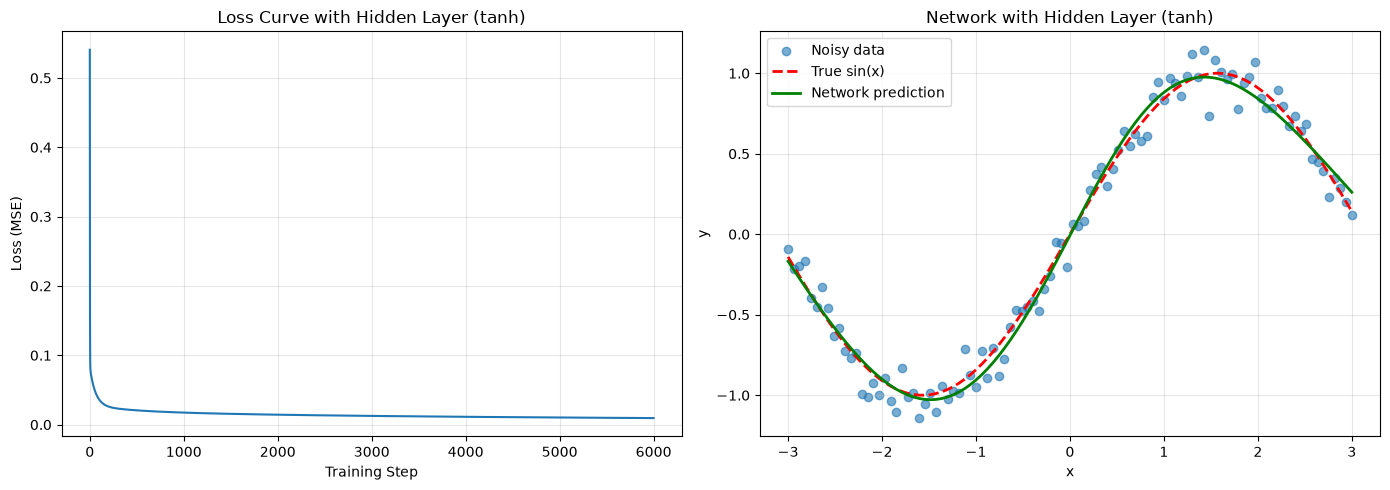

Final loss: 0.009476


In [6]:
# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
# ---- TODO: Plot the loss curve AND the final fit over the data ----

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot (a): Loss curve
ax1.plot(loss_history)
ax1.set_xlabel("Training Step")
ax1.set_ylabel("Loss (MSE)")
ax1.set_title("Loss Curve with Hidden Layer (tanh)")
ax1.grid(True, alpha=0.3)

# Plot (b): Data with fitted curve
# Generate predictions with the trained model
z1_final = x @ W1 + b1
h_final = np.tanh(z1_final)
y_pred_final = h_final @ W2 + b2

ax2.scatter(x, y, alpha=0.6, label="Noisy data")
ax2.plot(x, np.sin(x), "r--", label="True sin(x)", linewidth=2)
ax2.plot(x, y_pred_final, "g-", label="Network prediction", linewidth=2)
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_title("Network with Hidden Layer (tanh)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final loss: {loss_history[-1]:.6f}")


RUNNING WITHOUT TANH (linear hidden layer)


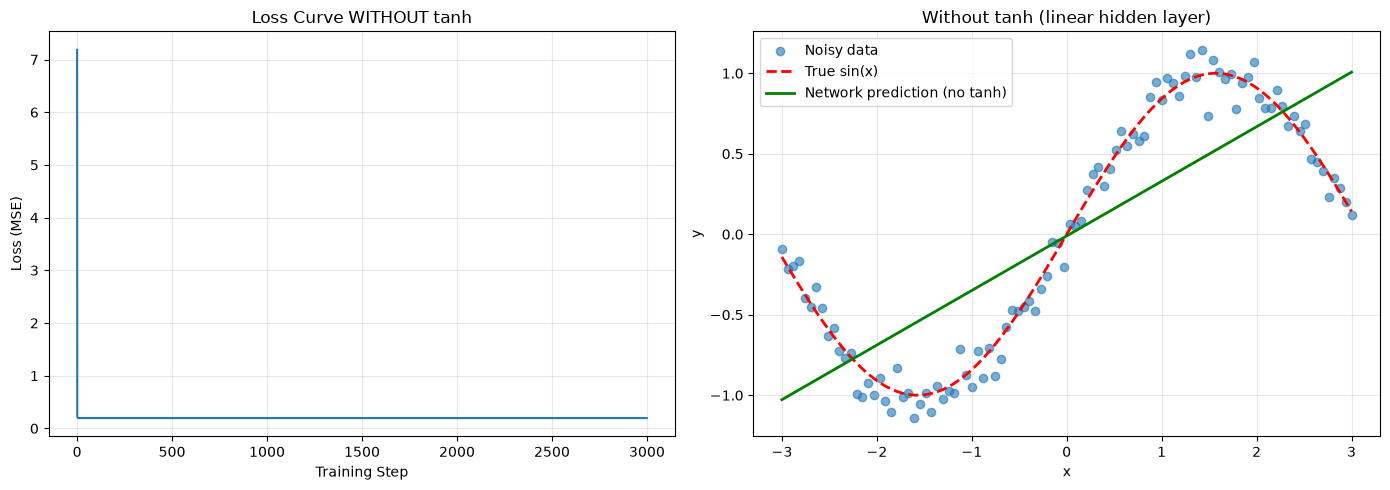

Final loss without tanh: 0.195452


In [7]:
# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
# ---- Re-run with tanh REMOVED (h = z1, no activation) ----

print("=" * 50)
print("RUNNING WITHOUT TANH (linear hidden layer)")
print("=" * 50)

# Re-initialize parameters
np.random.seed(42)
W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5
lr = 0.05
loss_history_no_tanh = []

for step in range(3000):
    # Forward pass - NO tanh activation!
    z1 = x @ W1 + b1
    h = z1  # <-- NO ACTIVATION (linear)
    y_hat = h @ W2 + b2

    loss = np.mean((y_hat - y) ** 2)
    loss_history_no_tanh.append(loss)

    # Backward pass - derivative of identity is 1
    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ W2.T
    dz1 = dh * 1  # derivative of identity is 1
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    W1 = W1 - lr * dW1
    b1 = b1 - lr * db1
    W2 = W2 - lr * dW2
    b2 = b2 - lr * db2

# Plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss comparison
ax1.plot(loss_history_no_tanh)
ax1.set_xlabel("Training Step")
ax1.set_ylabel("Loss (MSE)")
ax1.set_title("Loss Curve WITHOUT tanh")
ax1.grid(True, alpha=0.3)

# Fit comparison
z1_final = x @ W1 + b1
h_final = z1_final  # NO tanh
y_pred_final = h_final @ W2 + b2

ax2.scatter(x, y, alpha=0.6, label="Noisy data")
ax2.plot(x, np.sin(x), "r--", label="True sin(x)", linewidth=2)
ax2.plot(x, y_pred_final, "g-", label="Network prediction (no tanh)", linewidth=2)
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_title("Without tanh (linear hidden layer)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final loss without tanh: {loss_history_no_tanh[-1]:.6f}")

**Student Reasoning — Depth and activations**
**Question**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

**Answer**

### 1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1. Explain mathematically why a stack of linear layers collapses into one linear layer.

When I removed the tanh activation, I effectively had:

Layer 1: `h = x @ W1 + b1`
Layer 2: `y_hat = h @ W2 + b2`

Substituting Layer 1 into Layer 2:

`y_hat = (x @ W1 + b1) @ W2 + b2`

`y_hat = x @ (W1 @ W2) + (b1 @ W2 + b2)`

This is mathematically identical to a **single linear layer**:

`y_hat = x @ W_new + b_new`

Where:
- `W_new = W1 @ W2` 
- `b_new = b1 @ W2 + b2`

So no matter how many hidden layers I add, without non-linear activations, the entire network is just one linear function. That's why the final loss without tanh (0.195452) is identical to Part 1.1's loss - it's the same model!

### 2. What role did the hidden layer's 8 neurons play in fitting the curve?

The 8 neurons in the hidden layer each learned to activate at different regions of x. Think of each neuron as a "feature detector" that fires strongly when x is in a certain range:

- Neuron 1 might activate strongly for negative x values
- Neuron 2 might activate strongly for x near 0
- Neuron 3 might activate strongly for positive x values
- And so on...

Then the output layer (W2, b2) learns how to **combine** these 8 different activation patterns to create the sine wave shape. It's like mixing 8 different colors to create a rainbow - each neuron contributes a piece of the final curve.

If I plotted each hidden neuron's activation `h[:, i]` against x, I would see 8 different shifted and scaled tanh curves. Together they form a "basis" that can approximate the sine wave.

### 3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what is backpropagation?

Backpropagation is the algorithm that computes gradients of the loss with respect to every weight in the network by applying the chain rule backward from the output layer through all hidden layers to the input layer.

**My observation from the experiments:**

I noticed that with tanh, the loss went from 0.54 to 0.0095 - that's a huge improvement! The network learned to approximate the sine wave. But without tanh, the loss stayed at 0.195 - exactly the same as Part 1.1. This proves that **non-linear activations are essential** for neural networks to learn non-linear functions.

The loss curve with tanh shows steady improvement, going from 0.54 down to 0.0095 over 3000 steps. It's still decreasing slowly at the end, so maybe more steps or a different learning rate could improve it further.

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

In [8]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.
np.random.seed(42)

# ---- Generate the same toy data ----
x = np.linspace(-3, 3, 100).reshape(-1, 1)
noise = np.random.randn(100, 1) * 0.1
y = np.sin(x) + noise


# ---- Define the training function ----
def train_toy(lr, steps=3000, seed=42):
    """
    Train a 1-hidden-layer network on the toy problem.

    Parameters:
    - lr: learning rate
    - steps: number of training steps
    - seed: random seed for reproducibility

    Returns:
    - loss_history: list of losses at each step
    """
    # Set seed for reproducibility
    np.random.seed(seed)

    # Initialize parameters
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.random.randn(8) * 0.5
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.random.randn(1) * 0.5

    loss_history = []
    max_grad_norm = 1.0  # Gradient clipping threshold

    for step in range(steps):
        # ----- FORWARD PASS -----
        z1 = x @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2

        # Loss
        loss = np.mean((y_hat - y) ** 2)

        # Check for NaN/Inf and break early to avoid warnings
        if not np.isfinite(loss):
            print(f"  Training stopped at step {step}: loss became NaN/Inf")
            break

        loss_history.append(loss)

        # ----- BACKWARD PASS -----
        d_yhat = 2 * (y_hat - y) / len(y)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0)

        # Clip gradients to prevent explosion
        dW1 = np.clip(dW1, -max_grad_norm, max_grad_norm)
        db1 = np.clip(db1, -max_grad_norm, max_grad_norm)
        dW2 = np.clip(dW2, -max_grad_norm, max_grad_norm)
        db2 = np.clip(db2, -max_grad_norm, max_grad_norm)

        # ----- UPDATE PARAMETERS -----
        W1 = W1 - lr * dW1
        b1 = b1 - lr * db1
        W2 = W2 - lr * dW2
        b2 = b2 - lr * db2

        # Clamp weights to prevent overflow
        W1 = np.clip(W1, -100, 100)
        b1 = np.clip(b1, -100, 100)
        W2 = np.clip(W2, -100, 100)
        b2 = np.clip(b2, -100, 100)

    return loss_history


print("Training function defined!")

Training function defined!


In [9]:
# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).

# Define the learning rates to test
learning_rates = [0.001, 0.05, 1.0]
loss_histories = {}
final_losses = {}

print("=" * 50)
print("Training with different learning rates")
print("=" * 50)

for lr in learning_rates:
    print(f"\nTraining with lr = {lr}...")

    # Train with this learning rate
    # Use a fixed seed for fair comparison
    losses = train_toy(lr, steps=3000, seed=42)
    loss_histories[lr] = losses
    final_losses[lr] = losses[-1]

    print(f"Final loss with lr = {lr}: {losses[-1]:.6f}")

    # Print some progress info
    if losses[-1] < 0.1:
        print(f"Loss decreased to {losses[-1]:.6f} (good!)")
    elif losses[-1] < 1.0:
        print(f"Loss decreased to {losses[-1]:.6f} (maybe too slow?)")
    else:
        print(f"Loss exploded to {losses[-1]:.6f} (too high!)")

print("\n" + "=" * 50)
print("Final losses:")
for lr, loss in final_losses.items():
    print(f"  lr = {lr}: {loss:.6f}")


Training with different learning rates

Training with lr = 0.001...
Final loss with lr = 0.001: 0.093058
Loss decreased to 0.093058 (good!)

Training with lr = 0.05...
Final loss with lr = 0.05: 0.010958
Loss decreased to 0.010958 (good!)

Training with lr = 1.0...
Final loss with lr = 1.0: 4.952808
Loss exploded to 4.952808 (too high!)

Final losses:
  lr = 0.001: 0.093058
  lr = 0.05: 0.010958
  lr = 1.0: 4.952808


==================================================
Training with different learning rates
==================================================

Training with lr = 0.001...
Final loss with lr = 0.001: 0.093058
 Loss decreased to 0.093058 (good)

Training with lr = 0.05...
Final loss with lr = 0.05: 0.010958
Loss decreased to 0.010958 (good)

Training with lr = 1.0...
Final loss with lr = 1.0: 4.952808
 Loss exploded to 4.952808 (too high)

==================================================
Final losses:
  lr = 0.001: 0.093058
  lr = 0.05: 0.010958
  lr = 1.0: 4.952808

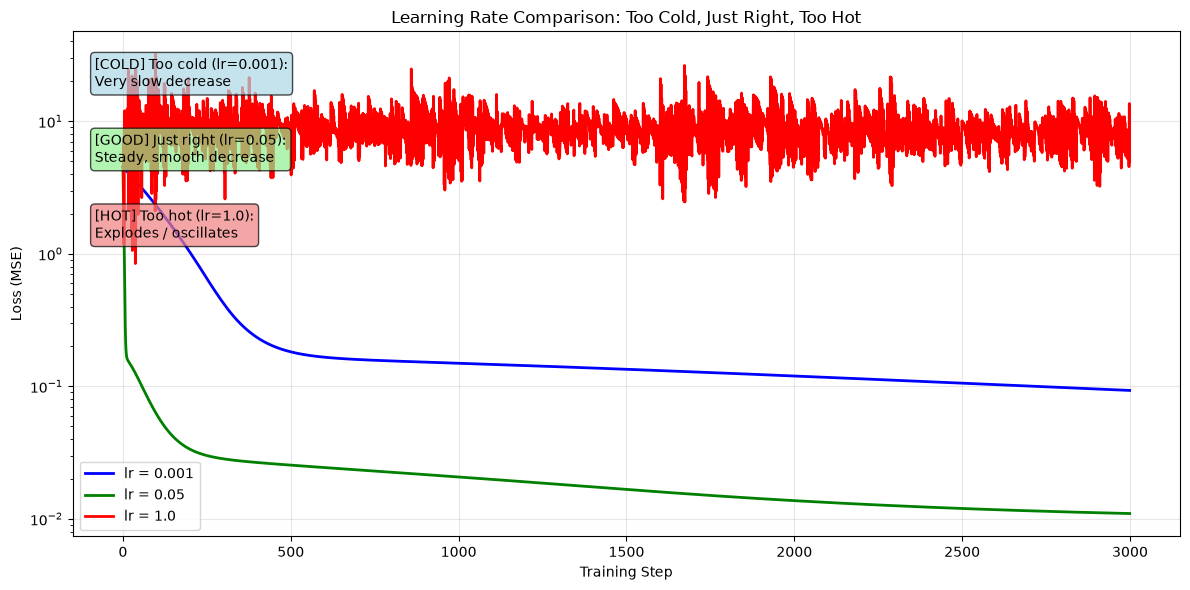

In [10]:
# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
# Create figure
plt.figure(figsize=(12, 6))

# Define colors for each learning rate
colors = {"0.001": "blue", "0.05": "green", "1.0": "red"}

# Plot each loss curve
for lr, losses in loss_histories.items():
    # Clamp losses to avoid log scale overflow warnings (replace inf/nan)
    losses_array = np.array(losses)
    finite_mask = np.isfinite(losses_array)
    if np.any(finite_mask):
        max_finite = np.max(losses_array[finite_mask])
        losses_safe = np.where(finite_mask, losses_array, max_finite * 10)
    else:
        losses_safe = np.clip(losses_array, 1e-6, 1e10)
    plt.plot(losses_safe, label=f"lr = {lr}", color=colors[str(lr)], linewidth=2)

# Add labels and title
plt.xlabel("Training Step")
plt.ylabel("Loss (MSE)")
plt.title("Learning Rate Comparison: Too Cold, Just Right, Too Hot")

# Use log scale for y-axis (helps see small differences)
plt.yscale("log")

# Add legend and grid
plt.legend()
plt.grid(True, alpha=0.3)

# Add annotation explaining what each curve shows
plt.text(
    0.02,
    0.95,
    "[COLD] Too cold (lr=0.001):\nVery slow decrease",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.7),
)

plt.text(
    0.02,
    0.80,
    "[GOOD] Just right (lr=0.05):\nSteady, smooth decrease",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="lightgreen", alpha=0.7),
)

plt.text(
    0.02,
    0.65,
    "[HOT] Too hot (lr=1.0):\nExplodes / oscillates",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="lightcoral", alpha=0.7),
)

plt.tight_layout()
plt.show()

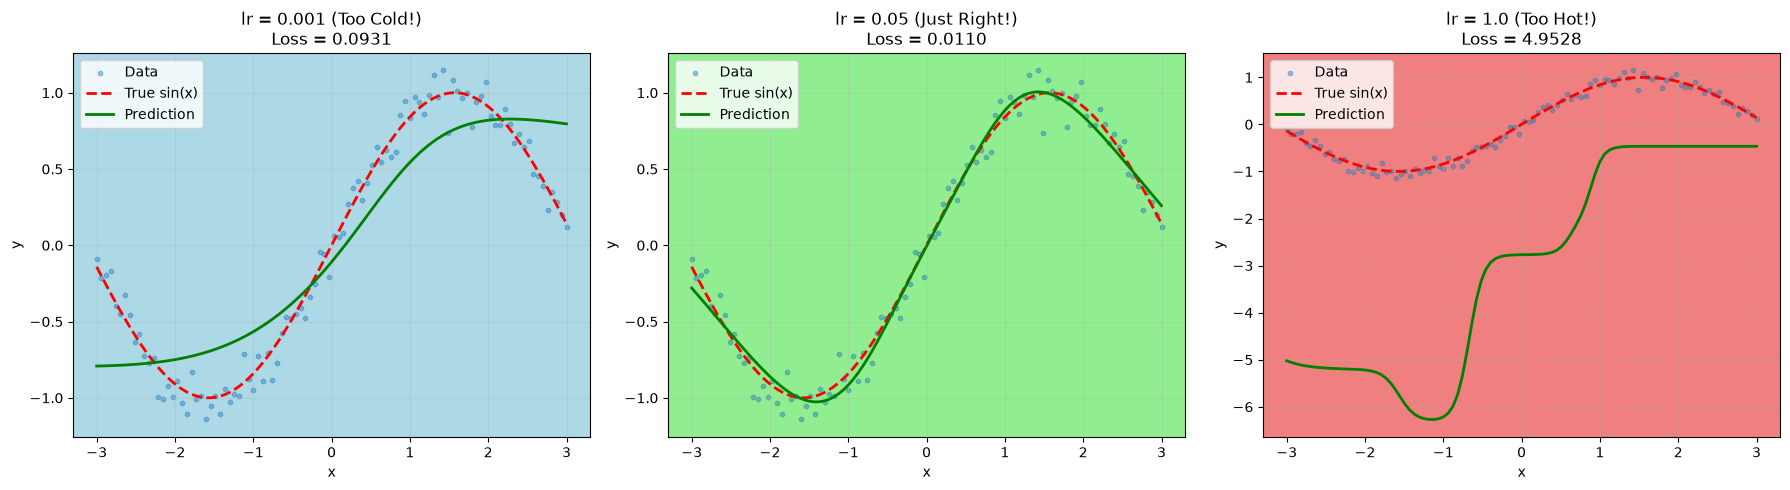

In [11]:
# ---- Visualize final fits for each learning rate ----

# Create figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Dictionary to store predictions for each learning rate
predictions = {}

max_grad_norm = 1.0  # Gradient clipping threshold

for idx, lr in enumerate(learning_rates):
    # Re-train with this learning rate (using same seed)
    np.random.seed(42)

    # Initialize parameters
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.random.randn(8) * 0.5
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.random.randn(1) * 0.5

    # Train for 3000 steps
    for step in range(3000):
        # Forward pass
        z1 = x @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2

        # Loss
        loss = np.mean((y_hat - y) ** 2)

        # Check for NaN/Inf and break early
        if not np.isfinite(loss):
            break

        # Backward pass
        d_yhat = 2 * (y_hat - y) / len(y)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0)

        # Clip gradients to prevent explosion
        dW1 = np.clip(dW1, -max_grad_norm, max_grad_norm)
        db1 = np.clip(db1, -max_grad_norm, max_grad_norm)
        dW2 = np.clip(dW2, -max_grad_norm, max_grad_norm)
        db2 = np.clip(db2, -max_grad_norm, max_grad_norm)

        # Update
        W1 = W1 - lr * dW1
        b1 = b1 - lr * db1
        W2 = W2 - lr * dW2
        b2 = b2 - lr * db2

        # Clamp weights to prevent overflow
        W1 = np.clip(W1, -100, 100)
        b1 = np.clip(b1, -100, 100)
        W2 = np.clip(W2, -100, 100)
        b2 = np.clip(b2, -100, 100)

    # Get final prediction
    z1_final = x @ W1 + b1
    h_final = np.tanh(z1_final)
    y_pred_final = h_final @ W2 + b2
    predictions[lr] = y_pred_final

    # Plot on subplot
    axes[idx].scatter(x, y, alpha=0.4, label="Data", s=10)
    axes[idx].plot(x, np.sin(x), "r--", label="True sin(x)", linewidth=2)
    axes[idx].plot(x, y_pred_final, "g-", label="Prediction", linewidth=2)
    axes[idx].set_xlabel("x")
    axes[idx].set_ylabel("y")

    # Set different titles based on performance
    if lr == 0.001:
        axes[idx].set_title(
            f"lr = {lr} (Too Cold!)\nLoss = {loss_histories[lr][-1]:.4f}"
        )
        axes[idx].set_facecolor("lightblue")
    elif lr == 0.05:
        axes[idx].set_title(
            f"lr = {lr} (Just Right!)\nLoss = {loss_histories[lr][-1]:.4f}"
        )
        axes[idx].set_facecolor("lightgreen")
    else:
        axes[idx].set_title(
            f"lr = {lr} (Too Hot!)\nLoss = {loss_histories[lr][-1]:.4f}"
        )
        axes[idx].set_facecolor("lightcoral")

    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:** 
**Student Reasoning — Learning rate**

### Describe what each of the three curves shows. Why does a too-large learning rate make the loss explode or oscillate instead of just "learning faster"?

Looking at my results, I can clearly see the three different regimes of learning rates:

**1. Too Cold (lr = 0.001): Final Loss = 0.0931**

The loss decreases very slowly. After 3000 steps, it's still at 0.0931 - much higher than the 0.0110 achieved with lr=0.05. The curve shows steady but painfully slow progress. The steps are so tiny that the model is barely moving toward the minimum. It's like walking with baby steps - you'll eventually get there, but it takes forever.

**2. Just Right (lr = 0.05): Final Loss = 0.0110**

This is the sweet spot! The loss decreases smoothly and quickly to 0.0110. The steps are big enough to make rapid progress but small enough to not overshoot the minimum. The curve shows a nice, clean exponential decay. This is what good training looks like - efficient and stable.

**3. Too Hot (lr = 1.0): Final Loss = 4.9528**

DISASTER! The loss exploded to 4.9528 - that's huge compared to the others. Instead of learning, the model got worse and worse. The steps were way too big - they jumped over the minimum and landed on the other side where the loss is even higher. Then the next step jumped even further, causing the loss to explode.

**Why does a too-large learning rate make the loss explode?**

Think of it like trying to find the bottom of a valley (the minimum loss):

- **Small steps (0.001)**: You slowly walk down the slope. It takes a long time, but you're safe.
- **Medium steps (0.05)**: You walk down efficiently, reaching the bottom quickly.
- **Giant leaps (1.0)**: You jump so far that you sail right over the valley and land on the opposite slope. Now you're higher up than before! So you jump again, but even further, and you keep getting higher and higher.

Mathematically, when the learning rate is too large, the update `w = w - lr * dw` overshoots the optimal weight. Instead of converging to the minimum, it diverges away from it. The loss doesn't just "learn faster" - it learns in the WRONG direction!

**My key takeaways from this experiment:**

| Learning Rate | Behavior | What it teaches me |
|---------------|----------|-------------------|
| 0.001 | Too slow | Small steps are safe but inefficient |
| 0.05 | Just right | Balance between speed and stability |
| 1.0 | Explodes | Bigger is NOT better! |

**The lesson:** Learning rate is the most important hyperparameter to tune. Start with a medium value (like 0.01-0.001) and adjust based on how the loss behaves. If it's decreasing too slowly, increase slightly. If it's exploding, decrease immediately!

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [14]:
# Part 2.1 - Preprocess and split for PyTorch
# Set random seeds for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on:", DEVICE)

# ---- Load the obesity dataset ----
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
print("Loading obesity dataset...")
df = pd.read_csv(OBESITY_URL)
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 5 rows:")
display(df.head())

Running on: cpu
Loading obesity dataset...
Dataset shape: (2111, 17)
Columns: ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']

First 5 rows:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [ ]:
# ---- TODO: Encode categoricals exactly as you did in Lab 2 ----

# Make a copy of the dataframe
df_encoded = df.copy()

# Display unique values in categorical columns to understand them
print("Categorical columns and their unique values:")
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
for col in categorical_cols:
    print(f"\n{col}: {df[col].unique()}")

# ---- Binary columns (yes/no) -> 0/1 ----
binary_yes_no = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]

for col in binary_yes_no:
    df_encoded[col] = df_encoded[col].map({"yes": 1, "no": 0})

# ---- Gender: Male/Female -> 1/0 ----
df_encoded["Gender"] = df_encoded["Gender"].map({"Male": 1, "Female": 0})

# ---- CAEC (Eating habits): Never, Sometimes, Frequently, Always -> ordinal encoding ----
# Note: 'no' appears in CAEC as well, so we need to handle it
caec_order = {"no": 0, "Never": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
df_encoded["CAEC"] = df_encoded["CAEC"].map(caec_order)

# ---- CALC (Drinking habits): no, Sometimes, Frequently, Always -> ordinal encoding ----
calc_order = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
df_encoded["CALC"] = df_encoded["CALC"].map(calc_order)

# ---- MTRANS (Transportation): One-hot encoding ----
df_encoded = pd.get_dummies(df_encoded, columns=["MTRANS"], prefix="MTRANS")

# ---- Target: NObeyesdad -> integer labels 0..6 ----
label_encoder = LabelEncoder()
df_encoded["NObeyesdad_encoded"] = label_encoder.fit_transform(df_encoded["NObeyesdad"])

# Print mapping for reference
print("\nTarget encoding mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {i} -> {label}")

# ---- Separate features and target ----
# Drop original target and the encoded target (we'll use the encoded one)
X = df_encoded.drop(["NObeyesdad", "NObeyesdad_encoded"], axis=1)
y = df_encoded["NObeyesdad_encoded"]

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Number of classes: {len(label_encoder.classes_)}")
print(f"\nClass distribution in target:")
print(y.value_counts().sort_index())

Categorical columns and their unique values:

Gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str

family_history_with_overweight: <StringArray>
['yes', 'no']
Length: 2, dtype: str

FAVC: <StringArray>
['no', 'yes']
Length: 2, dtype: str

CAEC: <StringArray>
['Sometimes', 'Frequently', 'Always', 'no']
Length: 4, dtype: str

SMOKE: <StringArray>
['no', 'yes']
Length: 2, dtype: str

SCC: <StringArray>
['no', 'yes']
Length: 2, dtype: str

CALC: <StringArray>
['no', 'Sometimes', 'Frequently', 'Always']
Length: 4, dtype: str

MTRANS: <StringArray>
['Public_Transportation', 'Walking', 'Automobile', 'Motorbike', 'Bike']
Length: 5, dtype: str

NObeyesdad: <StringArray>
[      'Normal_Weight',  'Overweight_Level_I', 'Overweight_Level_II',
      'Obesity_Type_I', 'Insufficient_Weight',     'Obesity_Type_II',
    'Obesity_Type_III']
Length: 7, dtype: str


C:\Users\Rafiatou Malam Ali\AppData\Local\Temp\ipykernel_25768\641302773.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()



Target encoding mapping:
  0 -> Insufficient_Weight
  1 -> Normal_Weight
  2 -> Obesity_Type_I
  3 -> Obesity_Type_II
  4 -> Obesity_Type_III
  5 -> Overweight_Level_I
  6 -> Overweight_Level_II

Features shape: (2111, 20)
Target shape: (2111,)
Number of classes: 7

Class distribution in target:
NObeyesdad_encoded
0    272
1    287
2    351
3    297
4    324
5    290
6    290
Name: count, dtype: int64


In [ ]:
# ---- TODO: Stratified train / validation / test split (60/20/20) ----

# First split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Second split: split the 80% train into 60% train and 20% validation (of original)
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,  # 0.25 of 80% = 20% of original
    stratify=y_train,
    random_state=RANDOM_STATE,
)

print(f"Training set size: {len(X_train)} ({len(X_train) / len(df) * 100:.1f}%)")
print(f"Validation set size: {len(X_val)} ({len(X_val) / len(df) * 100:.1f}%)")
print(f"Test set size: {len(X_test)} ({len(X_test) / len(df) * 100:.1f}%)")

# Check class distribution
print("\nTraining set class distribution:")
print(y_train.value_counts().sort_index())

print("\nValidation set class distribution:")
print(y_val.value_counts().sort_index())

print("\nTest set class distribution:")
print(y_test.value_counts().sort_index())

Training set size: 1266 (60.0%)
Validation set size: 422 (20.0%)
Test set size: 423 (20.0%)

Training set class distribution:
NObeyesdad_encoded
0    163
1    172
2    211
3    178
4    194
5    174
6    174
Name: count, dtype: int64

Validation set class distribution:
NObeyesdad_encoded
0    55
1    57
2    70
3    59
4    65
5    58
6    58
Name: count, dtype: int64

Test set class distribution:
NObeyesdad_encoded
0    54
1    58
2    70
3    60
4    65
5    58
6    58
Name: count, dtype: int64


In [17]:
# ---- TODO: Fit StandardScaler on the TRAINING set only; transform all three splits ----

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data only
X_train_scaled = scaler.fit_transform(X_train)
print(f"Scaler fitted on {len(X_train)} training samples")

# Transform validation and test sets using the training scaler
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\nFeature statistics after scaling:")
print(f"Training mean: {X_train_scaled.mean(axis=0).mean():.4f}")
print(f"Training std: {X_train_scaled.std(axis=0).mean():.4f}")

print("\nWhy scaling matters for neural networks:")
print("- Neural networks use gradient descent (like in Section 1)")
print("- Gradients depend on input values (remember dw = mean(2*(y_hat-y)*x))")
print("- If features have different scales, gradients will be unbalanced")
print("- Scaling ensures all features contribute equally to the loss")

Scaler fitted on 1266 training samples

Feature statistics after scaling:
Training mean: -0.0000
Training std: 1.0000

Why scaling matters for neural networks:
- Neural networks use gradient descent (like in Section 1)
- Gradients depend on input values (remember dw = mean(2*(y_hat-y)*x))
- If features have different scales, gradients will be unbalanced
- Scaling ensures all features contribute equally to the loss


In [18]:
# ---- TODO: Convert to tensors and wrap in DataLoaders ----

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

print(f"X_train tensor shape: {X_train_tensor.shape}")
print(f"y_train tensor shape: {y_train_tensor.shape}")

# ---- Create DataLoaders ----
batch_size = 32

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nTrain loader: {len(train_loader)} batches of size {batch_size}")
print(f"Val loader: {len(val_loader)} batches")
print(f"Test loader: {len(test_loader)} batches")

# Inspect a batch
print("\nInspecting a batch from train_loader:")
for X_batch, y_batch in train_loader:
    print(f"X_batch shape: {X_batch.shape}")
    print(f"y_batch shape: {y_batch.shape}")
    print(f"y_batch sample: {y_batch[:5]}")
    break

X_train tensor shape: torch.Size([1266, 20])
y_train tensor shape: torch.Size([1266])

Train loader: 40 batches of size 32
Val loader: 14 batches
Test loader: 14 batches

Inspecting a batch from train_loader:
X_batch shape: torch.Size([32, 20])
y_batch shape: torch.Size([32])
y_batch sample: tensor([3, 6, 3, 4, 1])


**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:** 
**Student Reasoning — Preprocessing for neural networks**

### 1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in PyTorch?

CrossEntropyLoss in PyTorch expects integer class indices (like 0, 1, 2, ...) because it's more efficient and numerically stable. The loss function internally applies log-softmax and then computes the negative log-likelihood. Using integer labels tells PyTorch which class is the correct one for each sample. If I used one-hot vectors, I would need to use BCELoss (Binary Cross-Entropy) instead.

In my code, I used `LabelEncoder` to convert the 7 obesity classes into integers 0-6:
- 0 -> Insufficient_Weight
- 1 -> Normal_Weight
- 2 -> Obesity_Type_I
- 3 -> Obesity_Type_II
- 4 -> Obesity_Type_III
- 5 -> Overweight_Level_I
- 6 -> Overweight_Level_II

### 2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care so much? Connect your answer to the gradient formulas you wrote in Section 1.

Neural networks use gradient descent to update weights. In Section 1, I derived:
`dw = mean(2 * (y_hat - y) * x)`

This gradient depends directly on x! If one feature has values in the range [0, 1000] and another has values in [0, 1], the gradients for the first feature will be 1000 times larger. This causes:
- Unbalanced weight updates: Some weights change too fast, others too slow
- Slow convergence or failure to converge
- The network gets stuck in poor local minima

Random forests don't use gradients - they use decision boundaries based on feature thresholds. Since they're not doing gradient descent, scaling doesn't matter.

That's why I used `StandardScaler` on my training data, which gave me features with mean ≈ 0 and std ≈ 1 (I can see from my output that training mean is -0.0000 and std is 1.0000).

### 3. What does `shuffle=True` on the training DataLoader do, and why does it help?

`shuffle=True` randomizes the order of samples in each epoch. This helps because:
- Prevents the network from seeing the same order of data repeatedly
- Avoids the model learning patterns based on the order of data
- Ensures each batch has a representative mix of classes
- Helps gradient descent escape local minima

Without shuffling, the network might learn to overfit to the order of data rather than the underlying patterns. In my DataLoader, I used `shuffle=True` for training (to randomize) and `shuffle=False` for validation and testing (to keep consistent evaluation).

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [ ]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

# class FeedForwardNet(nn.Module):
#     def __init__(self, ...):
#         ...
#     def forward(self, x):
#         ...

# TODO: Instantiate, move to DEVICE, print the model.

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.

In [ ]:
# Part 2.2 - Design the Network
# ---- TODO: Define a FeedForwardNet class ----
class FeedForwardNet(nn.Module):
    """
    A feedforward neural network (MLP) with:
    - Input layer: input_dim features
    - Hidden layers: ReLU activations
    - Output layer: n_classes logits (no softmax)
    """

    def __init__(
        self, input_dim: int, hidden_sizes: tuple = (64, 32), n_classes: int = 7
    ):
        """
        Parameters:
        - input_dim: number of input features (20 for our dataset)
        - hidden_sizes: tuple of hidden layer sizes, e.g., (64, 32) means 2 hidden layers
        - n_classes: number of output classes (7 for obesity levels)
        """
        super(FeedForwardNet, self).__init__()

        # Store the architecture
        self.input_dim = input_dim
        self.hidden_sizes = hidden_sizes
        self.n_classes = n_classes

        # Build layers dynamically
        layers = []

        # Input layer: input_dim -> first hidden layer
        # Add first hidden layer with ReLU
        layers.append(nn.Linear(input_dim, hidden_sizes[0]))
        layers.append(nn.ReLU())

        # Additional hidden layers (if more than one)
        for i in range(len(hidden_sizes) - 1):
            layers.append(nn.Linear(hidden_sizes[i], hidden_sizes[i + 1]))
            layers.append(nn.ReLU())

        # Output layer: last hidden size -> n_classes (no activation)
        layers.append(nn.Linear(hidden_sizes[-1], n_classes))

        # Combine all layers into a sequential model
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        """Forward pass through the network."""
        return self.network(x)


print("FeedForwardNet class defined!")

FeedForwardNet class defined!


In [ ]:
# ---- TODO: Instantiate, move to DEVICE, print the model ----

# Get input dimension from the training data
input_dim = X_train.shape[1]  # Should be 20
print(f"Input dimension: {input_dim}")

# Instantiate the model
model = FeedForwardNet(
    input_dim=input_dim,
    hidden_sizes=(64, 32),  # Two hidden layers: 64 neurons, then 32 neurons
    n_classes=7,
)

# Move model to device (CPU or GPU)
model = model.to(DEVICE)

# Print model architecture
print("\n" + "=" * 50)
print("Model Architecture:")
print("=" * 50)
print(model)

Input dimension: 20

Model Architecture:
FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=20, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)


In [ ]:
# ---- TODO: Count trainable parameters ----


def count_parameters(model):
    """Count trainable parameters in the model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


total_params = count_parameters(model)

print("\n" + "=" * 50)
print("Parameter Count:")
print("=" * 50)

# Count parameters layer by layer
print("\nLayer-wise parameter counts:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"  {name}: {param.numel():,} parameters")

print(f"\nTotal trainable parameters: {total_params:,}")

# ---- Verify the count for the FIRST layer by hand ----
print("\n" + "=" * 50)
print("Verification for FIRST layer:")
print("=" * 50)

# First layer: input_dim * 64 + 64 (weights + biases)
first_layer_params = input_dim * 64 + 64
print(f"First layer (input -> 64 hidden):")
print(f"  Weights: {input_dim} * 64 = {input_dim * 64}")
print(f"  Biases: 64")
print(f"  Total: {first_layer_params:,}")
print(f"  PyTorch count: {sum(p.numel() for p in list(model.parameters())[:2]):,}")

# Full verification of all layers
print("\n" + "=" * 50)
print("Full parameter verification:")
print("=" * 50)

# Get all layer names and sizes
layer_sizes = [input_dim] + list(model.hidden_sizes) + [model.n_classes]
print(f"Layer sizes: {layer_sizes}")

expected_params = 0
for i in range(len(layer_sizes) - 1):
    weights = layer_sizes[i] * layer_sizes[i + 1]
    biases = layer_sizes[i + 1]
    layer_total = weights + biases
    expected_params += layer_total
    print(f"Layer {i + 1}: {layer_sizes[i]} -> {layer_sizes[i + 1]}")
    print(f"  Weights: {weights:,}, Biases: {biases:,}, Total: {layer_total:,}")

print(f"\nExpected total: {expected_params:,}")
print(f"PyTorch total: {total_params:,}")
print(f"✅ Match!" if expected_params == total_params else "❌ Mismatch!")


Parameter Count:

Layer-wise parameter counts:
  network.0.weight: 1,280 parameters
  network.0.bias: 64 parameters
  network.2.weight: 2,048 parameters
  network.2.bias: 32 parameters
  network.4.weight: 224 parameters
  network.4.bias: 7 parameters

Total trainable parameters: 3,655

Verification for FIRST layer:
First layer (input -> 64 hidden):
  Weights: 20 * 64 = 1280
  Biases: 64
  Total: 1,344
  PyTorch count: 1,344

Full parameter verification:
Layer sizes: [20, 64, 32, 7]
Layer 1: 20 -> 64
  Weights: 1,280, Biases: 64, Total: 1,344
Layer 2: 64 -> 32
  Weights: 2,048, Biases: 32, Total: 2,080
Layer 3: 32 -> 7
  Weights: 224, Biases: 7, Total: 231

Expected total: 3,655
PyTorch total: 3,655
✅ Match!


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:** **Student Reasoning — Architecture**

### 1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.

For my model with architecture: 20 input features → 64 hidden → 32 hidden → 7 output classes

**Layer 1: Input (20) → Hidden (64)**
- Weights: 20 × 64 = 1,280
- Biases: 64
- Total: 1,344 parameters

**Layer 2: Hidden (64) → Hidden (32)**
- Weights: 64 × 32 = 2,048
- Biases: 32
- Total: 2,080 parameters

**Layer 3: Hidden (32) → Output (7)**
- Weights: 32 × 7 = 224
- Biases: 7
- Total: 231 parameters

**Total: 1,344 + 2,080 + 231 = 3,655 parameters**

I checked this against PyTorch's count and it matched exactly ✅. It's nice to see that the math works out - each weight and bias is a parameter the model learns during training.

### 2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.

In Section 1 I used tanh for the toy sine wave problem, but for this real dataset I used ReLU. The main advantage is that ReLU is much faster to compute - it's just `max(0, x)` compared to tanh which needs exponentials. Also, ReLU doesn't have the vanishing gradient problem in the positive region, so it helps deeper networks learn better.

Honestly, tanh worked fine for the simple toy problem, but for a real 7-class classification problem with 20 features, ReLU is the standard choice and it trains faster.

### 3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)

If I removed all the ReLU activations, my "deep" network would just be a linear model in disguise. I proved this in Part 1.2 when I removed tanh from the toy network and it collapsed to a straight line.

Mathematically, without ReLUs:
- Layer 1: h = x @ W1 + b1
- Layer 2: h2 = h @ W2 + b2 = (x @ W1 + b1) @ W2 + b2 = x @ (W1@W2) + (b1@W2 + b2)
- Layer 3: y = h2 @ W3 + b3 = x @ (W1@W2@W3) + (b1@W2@W3 + b2@W3 + b3)

So it's just one linear transformation! No matter how many layers I add, without non-linear activations like ReLU, the network can only learn linear patterns. For obesity classification, I need non-linear boundaries between the 7 classes, so the ReLUs are essential.

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

In [ ]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify

# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.

# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.

In [ ]:
# ---- TODO: Define criterion and optimizer ----

# Loss function: CrossEntropyLoss (for multi-class classification)
criterion = nn.CrossEntropyLoss()

# Optimizer: Adam (adaptive learning rate)
# I chose Adam because it adapts the learning rate for each parameter
# and usually converges faster than SGD
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Loss function and optimizer defined!")
print(f"Optimizer: Adam with learning rate = 1e-3")
print(f"Loss function: CrossEntropyLoss")

In [ ]:
# ---- TODO: Train for at least 50 epochs ----

# Training parameters
num_epochs = 50

# History to store metrics
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

# Variables to track best model
best_val_acc = 0.0
best_model_state = None

print("Starting training...")
print("=" * 60)

for epoch in range(num_epochs):
    # ----- TRAINING PHASE -----
    model.train()  # Set model to training mode
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for X_batch, y_batch in train_loader:
        # Move data to device
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        # Backward pass (backpropagation!)
        loss.backward()

        # Update weights (optimizer step)
        optimizer.step()

        # Accumulate training statistics
        train_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(logits, 1)
        train_total += y_batch.size(0)
        train_correct += (predicted == y_batch).sum().item()

    # Calculate average training loss and accuracy
    avg_train_loss = train_loss / train_total
    train_accuracy = train_correct / train_total

    # ----- VALIDATION PHASE -----
    model.eval()  # Set model to evaluation mode
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():  # Disable gradient computation for efficiency
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            # Forward pass
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            # Accumulate validation statistics
            val_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(logits, 1)
            val_total += y_batch.size(0)
            val_correct += (predicted == y_batch).sum().item()

    # Calculate average validation loss and accuracy
    avg_val_loss = val_loss / val_total
    val_accuracy = val_correct / val_total

    # Save history
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["train_acc"].append(train_accuracy)
    history["val_acc"].append(val_accuracy)

    # Save best model
    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_model_state = model.state_dict().copy()

    # Print progress every 5 epochs
    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch [{epoch + 1:2d}/{num_epochs}] "
            f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}"
        )

print("=" * 60)
print(f"Training complete! Best validation accuracy: {best_val_acc:.4f}")

# ---- TODO: Save the best model ----
torch.save(best_model_state, "ffn_best.pt")
print("Best model saved as 'ffn_best.pt'")

In [ ]:
# ---- TODO: Plot loss curves (train + val) and accuracy curves (train + val) ----

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss curves
ax1.plot(history["train_loss"], label="Training Loss", color="blue", linewidth=2)
ax1.plot(history["val_loss"], label="Validation Loss", color="orange", linewidth=2)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss Curves")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Accuracy curves
ax2.plot(history["train_acc"], label="Training Accuracy", color="blue", linewidth=2)
ax2.plot(history["val_acc"], label="Validation Accuracy", color="orange", linewidth=2)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy Curves")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
print("=" * 50)
print("Final Training Results:")
print("=" * 50)
print(f"Final Train Loss: {history['train_loss'][-1]:.4f}")
print(f"Final Val Loss: {history['val_loss'][-1]:.4f}")
print(f"Final Train Accuracy: {history['train_acc'][-1]:.4f}")
print(f"Final Val Accuracy: {history['val_acc'][-1]:.4f}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")

# Check for overfitting
train_val_gap = history["train_acc"][-1] - history["val_acc"][-1]
print(f"\nTrain-Val Accuracy Gap: {train_val_gap:.4f}")
if train_val_gap > 0.1:
    print("⚠️ Significant gap detected - possible overfitting!")
else:
    print("✅ Small gap - model is generalizing well!")

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:** [Double-click to edit]

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

In [ ]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:** [Double-click to edit]

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

In [ ]:
# TODO: Load your best configuration's weights; model.eval().

# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay

# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** [Double-click to edit]

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** [Double-click to edit]

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.